In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

import hmc
import func

In [ ]:
c = 2
mu1 = func.Ez(lambda z: z*np.tanh(c*z) )
sig_np = lambda x: np.tanh(c*x) - mu1*x
sig = lambda x: tf.nn.tanh(c*x) - mu1*x

# sig_np = lambda x: (x**3 - 3*x)/np.sqrt(6)
# sig = lambda x: (x**3 - 3*x)/np.sqrt(6)

g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig_np)

In [ ]:
d = 200
gamma = 0.5
Delta = 0.04

alpha = 1
k = int(gamma*d)
n = int(alpha*d**2)

beta = 1
v_np = func.v_generate(k, beta) # v numpy
mmse_theory, qw_theory = func.solve(n, d, Delta, v_np, g, m_e)
p = np.argmin(qw_theory>0) # number of learned features

v = tf.constant(v_np, dtype=tf.float32)
ntest = 40000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)


I0000 00:00:1774605612.193067   65348 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14242 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [5]:
params = {'step_size': 0.01,
          'num_leapfrog_steps': 10,
          'num_adaptation_steps': 2000
         }

W0, X, Y = hmc.data_generate(d, k, n, Delta, sig, v)

# partially informative init
top = W0[:p, :]
bottom = tf.random.normal((k - p, d), dtype=tf.float32)
W_init = tf.concat([top, bottom], axis=0)

Ws = hmc.hmc(params, W_init, v, X, Y, Delta, sig)
test_errs = [hmc.test_error(W, W0, v, sig, Xtest) for W in Ws]

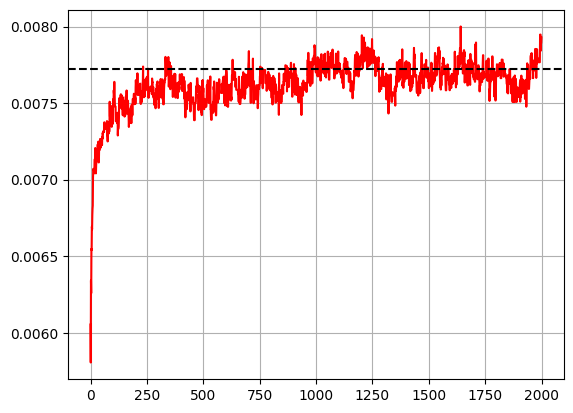

In [7]:
plt.plot(test_errs, color='red')
plt.axhline(y=mmse_theory, color='black', linestyle='--')
plt.grid()
plt.show()

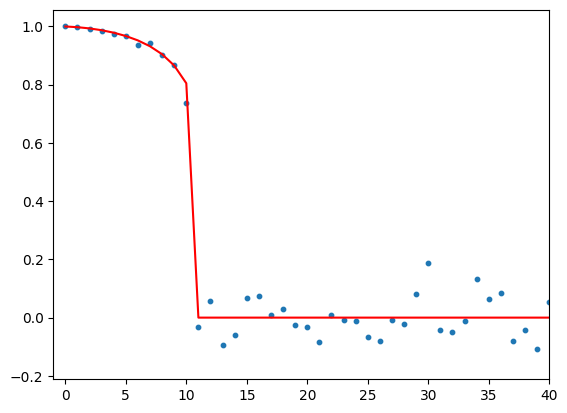

In [8]:
Wf = Ws[-1]
aligns = [func.align(Wf[i], W0[i]) for i in range(k)]
plt.scatter(np.arange(k), aligns, s=10)
plt.plot(qw_theory, color='red')
plt.xlim(-1, 40)
plt.show()

In [ ]:
# Wf = Ws[10]
# S = (W0@tf.transpose(Wf)/d).numpy()

# m=100
# S = S[:m,:m]

# fig, ax = plt.subplots(figsize=(5, 4), tight_layout=True)
# fig.colorbar(ax.imshow(S**2, cmap='hot', aspect='auto'))
# plt.show()